In [261]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance
!pip install mlxtend
from mlxtend.plotting import plot_decision_regions 
from sklearn.ensemble import RandomForestClassifier


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [103]:
seattle = pd.read_csv("listings.csv.gz")
seattle.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [104]:
# turn price into string
seattle["price"] = (
    seattle["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

In [105]:
# fill null with 0
seattle = seattle.fillna(0)
# filter price <= 0
seattle = seattle[seattle["price"] > 0]
# remove extreme price
p99_seattle = seattle["price"].quantile(0.99)
seattle = seattle[seattle["price"] <= p99_seattle]

In [107]:
# remove extreme value
p99_bedroom = seattle["bedrooms"].quantile(0.99)
p99_beds = seattle["beds"].quantile(0.99)
p99_bathroom = seattle["bathrooms"].quantile(0.99)
p99_accomodates = seattle["accommodates"].quantile(0.99)
seattle = seattle[seattle["bedrooms"] <= p99_bedroom]
seattle = seattle[seattle["beds"] <= p99_beds]
seattle = seattle[seattle["bathrooms"] <= p99_bathroom]
seattle = seattle[seattle["accommodates"] <= p99_accomodates]
seattle

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,6606,https://www.airbnb.com/rooms/6606,20250925032813,2025-09-25,city scrape,"Fab, private seattle urban cottage!","This tiny cottage is only 15x10, but it has ev...","A peaceful yet highly accessible neighborhood,...",https://a0.muscache.com/pictures/45742/21116d7...,14942,...,4.77,4.88,4.57,str-opli-19-002622,f,3,3,0,0,0.82
1,9419,https://www.airbnb.com/rooms/9419,20250925032813,2025-09-25,city scrape,Glorious sun room w/ memory foambed,This beautiful double room features sun filled...,"Lots of restaurants (see our guide book) bars,...",https://a0.muscache.com/pictures/56645186/e5fb...,30559,...,4.89,4.70,4.69,Exempt,f,10,0,10,0,1.19
3,11012,https://www.airbnb.com/rooms/11012,20250925032813,2025-09-25,city scrape,"the orange house, quiet 'n central",0,0,https://a0.muscache.com/pictures/682034/54bc27...,14942,...,4.72,4.86,4.74,str-opli-19-002622,f,3,3,0,0,0.51
4,25002,https://www.airbnb.com/rooms/25002,20250925032813,2025-09-25,city scrape,Beautiful Private Spot in North Ballard,"-Great eating , Delancey, Fat Hen, 3 blocks aw...",Great walking neighborhood! We are in between...,https://a0.muscache.com/pictures/491561/cf5270...,102684,...,4.98,4.90,4.90,STR-OPLI-19-002617,t,1,1,0,0,6.06
5,26795,https://www.airbnb.com/rooms/26795,20250925032813,2025-09-25,city scrape,Lake Union Cottage - Shore and City View,"This sunny, corner lot is directly across from...",This area of the Eastlake Neighborhood is quie...,https://a0.muscache.com/pictures/179416/54927c...,114228,...,4.58,4.83,4.36,0,f,1,1,0,0,0.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6991,1515445606707131986,https://www.airbnb.com/rooms/1515445606707131986,20250925032813,2025-09-25,city scrape,Centrally located private room in shoreline-2,"Private room and bathroom in a townhome, centr...",0,https://a0.muscache.com/pictures/hosting/Hosti...,127525192,...,0.00,0.00,0.00,STR-OPLI-25-002944,f,3,0,3,0,0.00
6992,1515452490876536616,https://www.airbnb.com/rooms/1515452490876536616,20250925032813,2025-09-25,city scrape,Centrally located private room in Shoreline-3,"Private room and bathroom in a townhome, centr...",0,https://a0.muscache.com/pictures/hosting/Hosti...,127525192,...,0.00,0.00,0.00,STR-OPLI-25-002944,f,3,0,3,0,0.00
6993,1516340815301554136,https://www.airbnb.com/rooms/1516340815301554136,20250925032813,2025-09-25,city scrape,"Top floor oasis, comfortable and elegant.",This oasis is a perfect place to recover from ...,0,https://a0.muscache.com/pictures/hosting/Hosti...,308306114,...,0.00,0.00,0.00,STR-OPLI-19-803339,f,2,1,1,0,0.00
6994,1516722602078881683,https://www.airbnb.com/rooms/1516722602078881683,20250925032813,2025-09-25,city scrape,"Blueground | West Queen Anne, view, nr Kerry Park","Discover the best of Seattle, with this one be...",0,https://a0.muscache.com/pictures/prohost-api/H...,107434423,...,0.00,0.00,0.00,0,t,344,344,0,0,0.00


In [108]:
%cd imt574_ml_final_project
%pwd

/Users/peiyingw/imt574_ml_final_project


'/Users/peiyingw/imt574_ml_final_project'

In [109]:
seattle.to_csv('seattle_filtered.csv', index=False)

### Features (Fixed)
1) Relative Pricing	
- (price / average pricing) of listings with same conditions (same neighborhood, # of bedrooms and bathrooms, and roomtype)
2) Housing Characteristics:
- Room Type 
- num of Bedrooms
- num of Bathrooms
- num of Beds
- num of Accommodates
- Is_Long_term: 1 if minimum_nights > 7, 0 if minimum_nights <= 7
3) Host Characteristics:
- Host_Response TIme
- Host_Identity_Verified
4) Other Users Experience/Engagement:
- number_of_reviews (TBD vvn: check the colinearity btw scoring and num of review)
- recent_Review_proportion : number_of_reviews_ltm / number_of_reviews
- estimated_occupancy_l365d


In [220]:
sea = pd.read_csv("seattle_filtered.csv")

In [221]:
sea.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [222]:
# create relative price columns
# Relative Pricing =  Pricing / Mean Pricing of listings with same neighborhood, # of bedrooms and bathrooms, and roomtype
group_cols = ["bedrooms", "bathrooms", "neighbourhood_cleansed", "room_type"]
sea["avg_price_group"] = sea.groupby(group_cols)["price"].transform("mean")
sea["relative_price"] = sea["price"] / sea["avg_price_group"]

In [223]:
# host response time
mapping_host_response_time = {
    'within an hour': 1,
    'within a few hours': 2,
    'within a day': 3,
    'a few days or more': 4
}

sea['host_response_time'] = sea['host_response_time'].map(mapping_host_response_time)

In [224]:
# is_long_term
## minimum nights -> short-term listing vs. long-term listing
sea['is_long_term'] = (sea["minimum_nights"] > 7).astype(int)

In [225]:
# recent_Review_proportion : number_of_reviews_ltm / number_of_reviews
sea['recent_Review_proportion'] = sea['number_of_reviews_ltm'] / sea['number_of_reviews']

In [356]:
features = [
    "review_scores_rating",
    # relative pricing
    "relative_price",
    # housing characteristics
    "bedrooms",
    "beds",
    "bathrooms",
    "accommodates",
    "room_type",
    "is_long_term",
    # host characteristics
    "host_response_time",
    "host_identity_verified", 
    # others
    "number_of_reviews",
    "recent_Review_proportion",
    "estimated_occupancy_l365d"
]

In [227]:
df_sea = sea[features]
# drop na
df_drop = df_sea.dropna()
# fill na with 0
df_sea = df_sea.fillna(0)

In [228]:
sea.shape

(6072, 83)

In [229]:
df_sea.shape

(6072, 13)

In [230]:
df_drop.shape

(4872, 13)

In [28]:
# create relative price columns
# Relative Pricing =  Pricing / Mean Pricing of listings with same neighborhood, # of bedrooms and bathrooms, and roomtype
group_cols = ["bedrooms", "bathrooms", "neighbourhood_cleansed", "room_type"]
seattle["avg_price_group"] = seattle.groupby(group_cols)["price"].transform("mean")
seattle["relative_price"] = seattle["price"] / seattle["avg_price_group"]

In [88]:
features = [
    
    # relative pricing
    "relative_price",
    # housing characteristics
    "bedrooms",
    "beds",
    "bathrooms",
    "accommodates",
    "neighbourhood",
    "minimum_nights",
    "room_type",
    # host characteristics
    "host_response_time",
    # "host_is_superhost", 
    # others
    # "number_of_reviews",
    # "number_of_reviews_ltm",
    # "number_of_reviews_l30d"
]

In [89]:
df_sea = seattle[features]
df_sea = df_sea.fillna(0)
df_sea

,relative_price,bedrooms,beds,bathrooms,accommodates,neighbourhood,minimum_nights,room_type,host_response_time
0,0.772909,1.0,1.0,1.0,1,Neighborhood highlights,30,Entire home/apt,within a few hours
1,0.984592,1.0,2.0,3.0,2,Neighborhood highlights,2,Private room,within an hour
3,1.232497,3.0,3.0,2.0,8,0,30,Entire home/apt,within a few hours
4,0.741860,1.0,2.0,1.0,4,Neighborhood highlights,2,Entire home/apt,within an hour
5,0.969773,2.0,3.0,1.0,3,Neighborhood highlights,30,Entire home/apt,within a few hours
...,...,...,...,...,...,...,...,...,...
6991,1.091398,1.0,1.0,1.5,2,0,1,Private room,0
6992,1.091398,1.0,1.0,1.5,2,0,1,Private room,0
6993,1.000000,1.0,1.0,1.0,2,0,3,Private room,within a few hours
6994,1.073869,1.0,1.0,1.0,2,0,30,Entire home/apt,0


In [231]:
# target variable: review_score_rating
## high v.s. low score: scores >= 4.9
y = (df_sea["review_scores_rating"] >= 4.9).astype(int)

In [232]:
y.value_counts()

review_scores_rating
0    3274
1    2798
Name: count, dtype: int64

In [233]:
print(f"Baseline Accuracy: ",3274 / (3274+2798))

Baseline Accuracy:  0.5391963109354414


In [237]:
X = df_sea.drop(columns=["review_scores_rating"])
X = pd.get_dummies(X, drop_first = True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [238]:
X

,relative_price,bedrooms,beds,bathrooms,accommodates,is_long_term,host_response_time,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d,room_type_Private room,room_type_Shared room,host_identity_verified_f,host_identity_verified_t
0,0.772909,1.0,1.0,1.0,1,1,2.0,161,0.000000,0,False,False,False,True
1,0.984592,1.0,2.0,3.0,2,0,1.0,220,0.063636,84,True,False,False,True
2,1.232497,3.0,3.0,2.0,8,1,2.0,98,0.000000,0,False,False,False,True
3,0.741860,1.0,2.0,1.0,4,0,1.0,1139,0.054434,255,False,False,False,True
4,0.969773,2.0,3.0,1.0,3,1,2.0,64,0.000000,0,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6067,1.091398,1.0,1.0,1.5,2,0,0.0,0,0.000000,0,True,False,False,True
6068,1.091398,1.0,1.0,1.5,2,0,0.0,0,0.000000,0,True,False,False,True
6069,1.000000,1.0,1.0,1.0,2,0,2.0,0,0.000000,0,True,False,True,False
6070,1.073869,1.0,1.0,1.0,2,1,0.0,0,0.000000,0,False,False,False,False


##### Deciding k-values (k = 43)

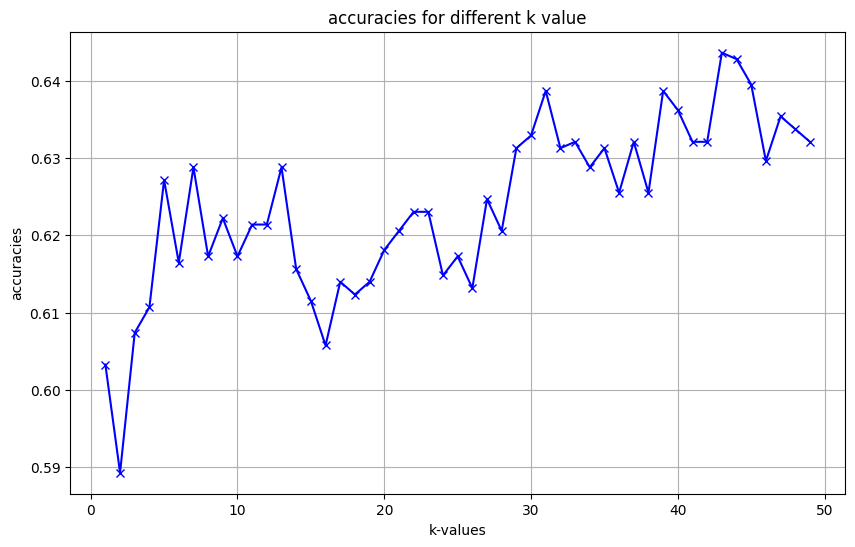

In [244]:
k_values = range(1, 50)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    accuracies.append(acc)

# data viz
x = np.arange(1,50)
plt.figure(figsize=(10, 6))
plt.plot(x, accuracies, 'bx-')
plt.xlabel('k-values')
plt.ylabel('accuracies')
plt.title('accuracies for different k value')
plt.grid(True)
plt.show()

##### Model Performance

In [245]:
clf = KNeighborsClassifier(n_neighbors= 43)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# Calculate precision
precision = precision_score(y_test, y_pred)

# Evaluate the model
print("\nAccuracy:")
print(clf.score(X_test, y_test))
print("\nPrecision Score:")
print(precision)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy:
0.6436213991769547

Precision Score:
0.6177924217462932

Confusion Matrix:
[[407 232]
 [201 375]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.64      0.65       639
           1       0.62      0.65      0.63       576

    accuracy                           0.64      1215
   macro avg       0.64      0.64      0.64      1215
weighted avg       0.64      0.64      0.64      1215



In [246]:
# target variable: review_score_rating
## high v.s. low score: scores >= 4.9
y_d = (df_drop["review_scores_rating"] >= 4.9).astype(int)

In [247]:
y_d.value_counts()

review_scores_rating
1    2568
0    2304
Name: count, dtype: int64

In [248]:
X_d = df_drop.drop(columns=["review_scores_rating"])
X_d = pd.get_dummies(X_d, drop_first = True)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42
)

In [249]:
X_d

,relative_price,bedrooms,beds,bathrooms,accommodates,is_long_term,host_response_time,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d,room_type_Private room,room_type_Shared room,host_identity_verified_t
0,0.772909,1.0,1.0,1.0,1,1,2.0,161,0.000000,0,False,False,True
1,0.984592,1.0,2.0,3.0,2,0,1.0,220,0.063636,84,True,False,True
2,1.232497,3.0,3.0,2.0,8,1,2.0,98,0.000000,0,False,False,True
3,0.741860,1.0,2.0,1.0,4,0,1.0,1139,0.054434,255,False,False,True
4,0.969773,2.0,3.0,1.0,3,1,2.0,64,0.000000,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6004,0.770687,1.0,1.0,1.0,2,0,1.0,3,1.000000,18,False,False,True
6007,0.898058,3.0,3.0,3.5,6,0,1.0,2,1.000000,12,False,False,False
6018,1.124479,2.0,2.0,2.0,4,0,1.0,1,1.000000,6,False,False,True
6026,0.952474,1.0,2.0,1.0,3,0,1.0,3,1.000000,18,False,False,True


##### Deciding k-values (k = 43)

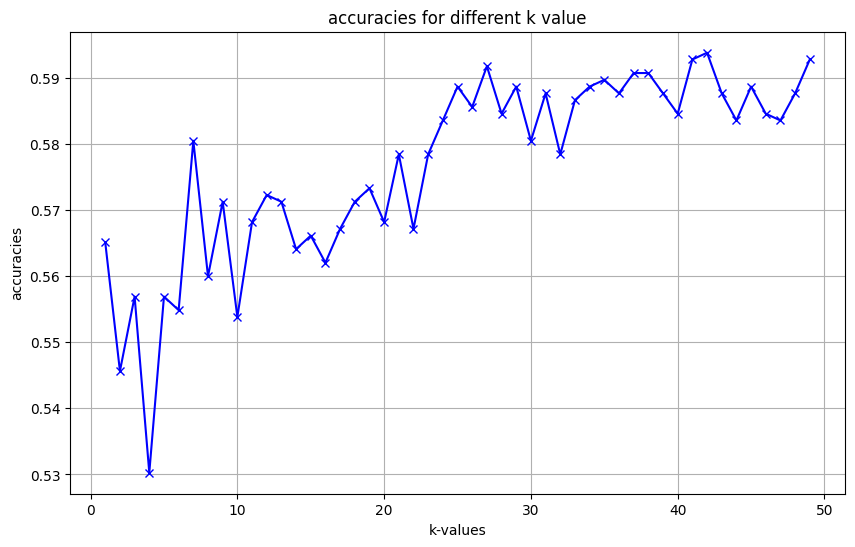

In [252]:
k_values = range(1, 50)
accuracies_d = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_d, y_train_d)
    
    y_pred_d = model.predict(X_test_d)
    acc = accuracy_score(y_test_d, y_pred_d)
    
    accuracies_d.append(acc)

# data viz
x = np.arange(1,50)
plt.figure(figsize=(10, 6))
plt.plot(x, accuracies_d, 'bx-')
plt.xlabel('k-values')
plt.ylabel('accuracies')
plt.title('accuracies for different k value')
plt.grid(True)
plt.show()

##### Model Performance

In [253]:
clf = KNeighborsClassifier(n_neighbors=43)
clf.fit(X_train_d, y_train_d)

y_pred_d = clf.predict(X_test_d)

# Calculate precision
precision_d = precision_score(y_test_d, y_pred_d)

# Evaluate the model
print("\nAccuracy:")
print(clf.score(X_test_d, y_test_d))
print("\nPrecision Score:")
print(precision_d)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_d, y_pred_d))
print("\nClassification Report:")
print(classification_report(y_test_d, y_pred_d))


Accuracy:
0.5876923076923077

Precision Score:
0.5894568690095847

Confusion Matrix:
[[204 257]
 [145 369]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.44      0.50       461
           1       0.59      0.72      0.65       514

    accuracy                           0.59       975
   macro avg       0.59      0.58      0.58       975
weighted avg       0.59      0.59      0.58       975



### Neighborhood Analysis (RF)

In [355]:
sea['neighbourhood_group_cleansed'].unique()

array(['Other neighborhoods', 'Ballard', 'Cascade', 'Rainier Valley',
       'Magnolia', 'West Seattle', 'Queen Anne', 'Downtown',
       'Capitol Hill', 'Beacon Hill', 'Lake City', 'Central Area',
       'University District', 'Delridge', 'Northgate', 'Seward Park',
       'Interbay'], dtype=object)

In [348]:
def run_rf_by_area(df, area_name, target_col="review_scores_rating", min_rows=30,
                   test_size=0.2, random_state=42, plot_top_n=10):
    df = df.dropna(subset=[target_col]).copy()

    if len(df) < min_rows:
        raise ValueError(f"{area_name}: Not enough rows ({len(df)})")

    # threshold
    thres = df[target_col].quantile(0.5)

    # X, y
    X = df.drop(columns=[target_col]).copy()
    y = (df[target_col] >= thres).astype(int)

    # one-hot encoding
    X = pd.get_dummies(X, drop_first=True)

    if y.nunique() < 2:
        raise ValueError(f"{area_name}: Only one class in target")

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # model
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=random_state
    )
    rf.fit(X_train, y_train)

    # prediction
    y_pred = rf.predict(X_test)

    # feature importance
    importance = pd.Series(
        rf.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)

    top_features = importance.head(plot_top_n)

    # results
    result = {
        "area": area_name,
        "threshold": thres,
        "accuracy": accuracy_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "feature_importance": importance,
        "top_features": top_features,
        "model": rf
    }

    return result

In [357]:
# area list
area_dfs = [
    "Downtown",
    "Central Area",
    "Queen Anne",
    "Beacon Hill",
    "Capitol Hill",
    "West Seattle",
    "Ballard",
    "Rainier Valley",
    "Cascade",
    "Northgate",
    "University District"]

all_results = {}

for i in range(len(area_dfs)):
    try:
        tmp = sea[sea['neighbourhood_group_cleansed'] == area_dfs[i]]
        tmp = tmp[features]
        result = run_rf_by_area(tmp, area_dfs[i])
        all_results[area_dfs[i]] = result
        print(f"\n=== {area_dfs[i]} ===")
        print("Threshold:", result["threshold"])
        print("Accuracy:", result["accuracy"])
        print("Confusion Matrix:\n", result["confusion_matrix"])
    except Exception as e:
        print(f"\n=== {area_dfs[i]} ===")
        print("Error:", e)


=== Downtown ===
Threshold: 4.81
Accuracy: 0.777027027027027
Confusion Matrix:
 [[48 25]
 [ 8 67]]

=== Central Area ===
Threshold: 4.88
Accuracy: 0.7241379310344828
Confusion Matrix:
 [[34 22]
 [10 50]]

=== Queen Anne ===
Threshold: 4.89
Accuracy: 0.6666666666666666
Confusion Matrix:
 [[29 20]
 [13 37]]

=== Beacon Hill ===
Threshold: 4.88
Accuracy: 0.6
Confusion Matrix:
 [[11 13]
 [ 7 19]]

=== Capitol Hill ===
Threshold: 4.85
Accuracy: 0.8
Confusion Matrix:
 [[43 11]
 [11 45]]

=== West Seattle ===
Threshold: 4.94
Accuracy: 0.5977011494252874
Confusion Matrix:
 [[20 20]
 [15 32]]

=== Ballard ===
Threshold: 4.94
Accuracy: 0.6438356164383562
Confusion Matrix:
 [[23 12]
 [14 24]]

=== Rainier Valley ===
Threshold: 4.88
Accuracy: 0.696969696969697
Confusion Matrix:
 [[20 13]
 [ 7 26]]

=== Cascade ===
Threshold: 4.0
Accuracy: 0.9387755102040817
Confusion Matrix:
 [[20  3]
 [ 0 26]]

=== Northgate ===
Threshold: 4.83
Accuracy: 0.6341463414634146
Confusion Matrix:
 [[10 10]
 [ 5 16]]



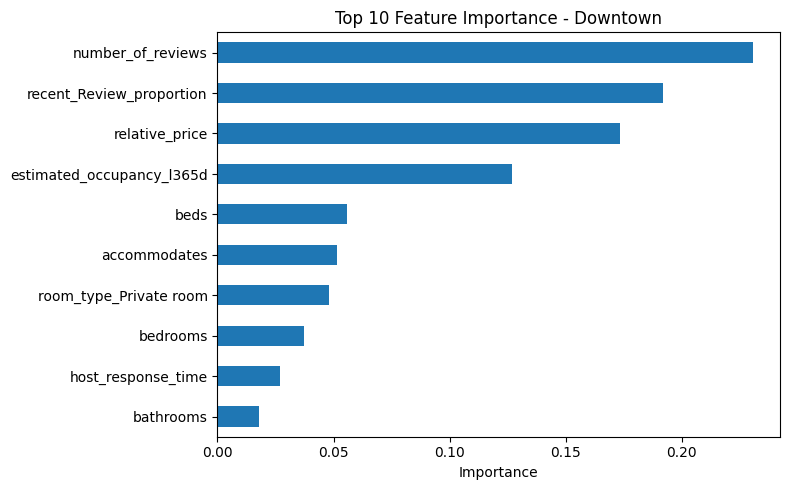

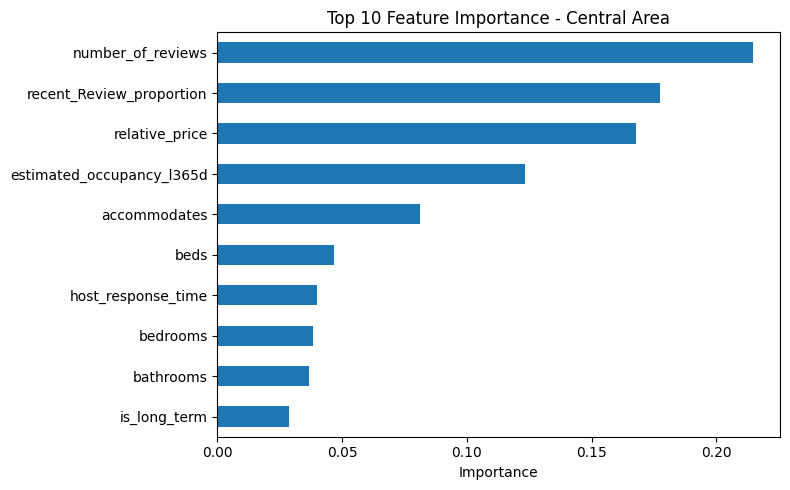

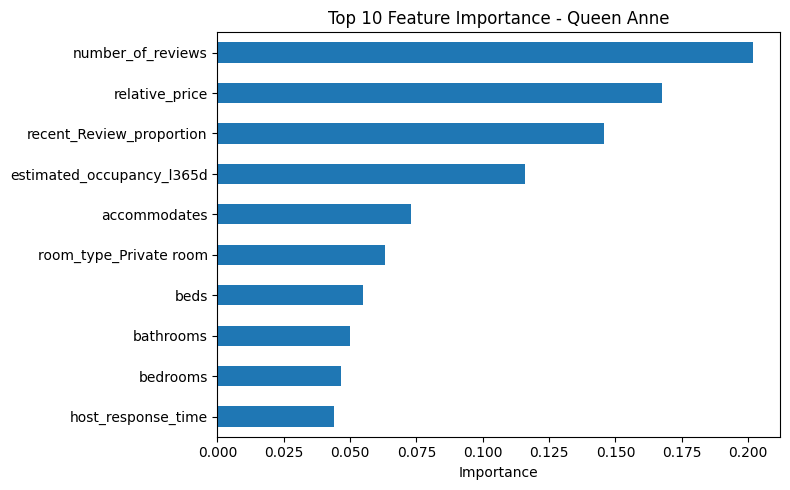

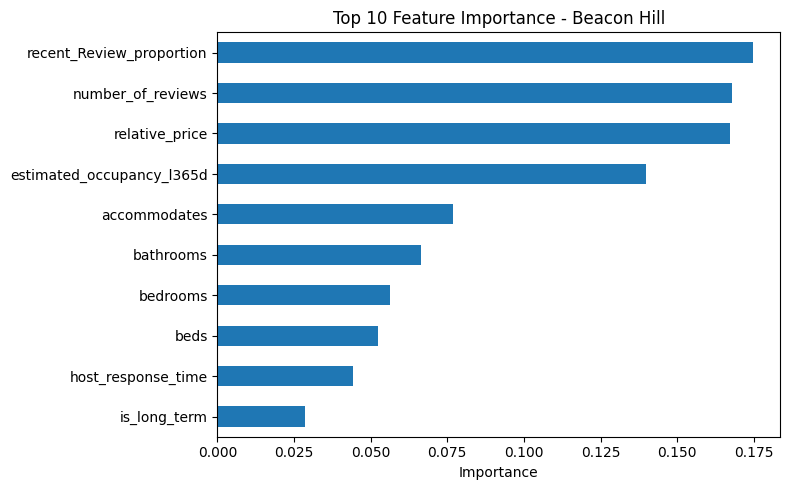

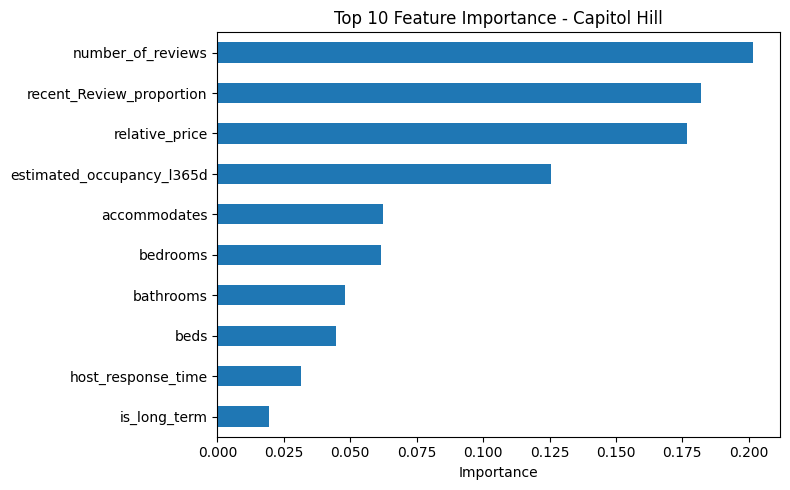

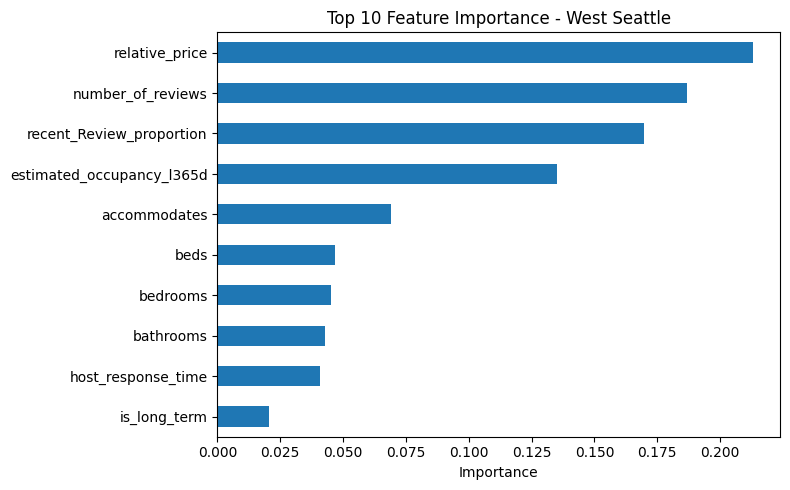

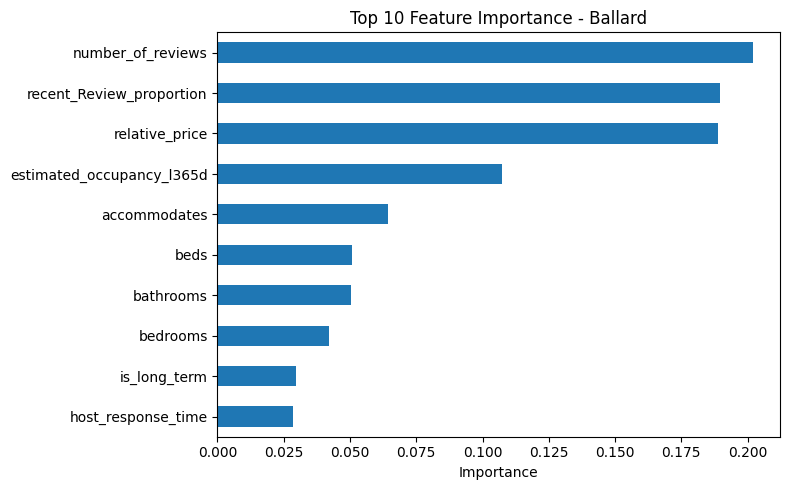

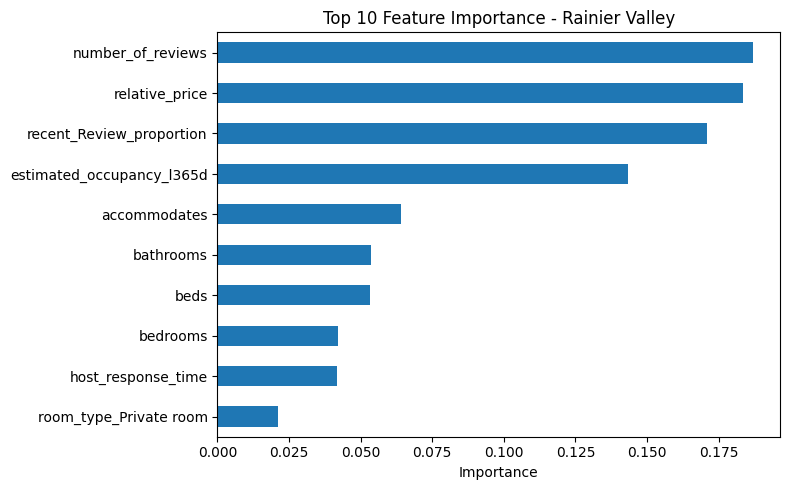

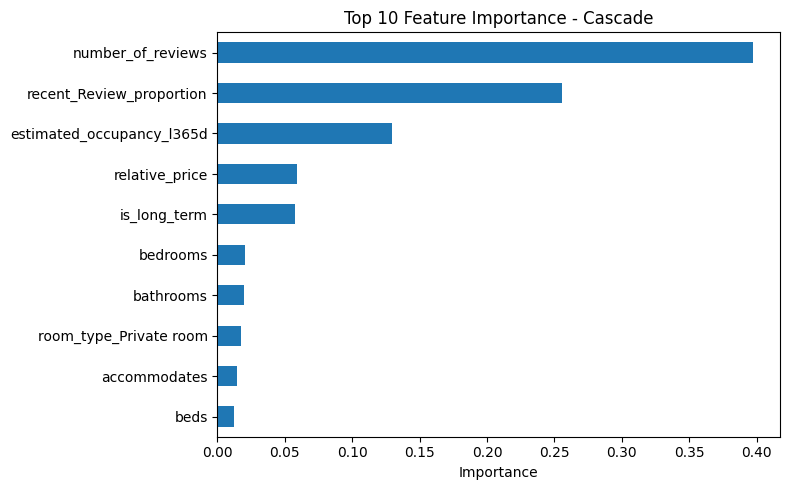

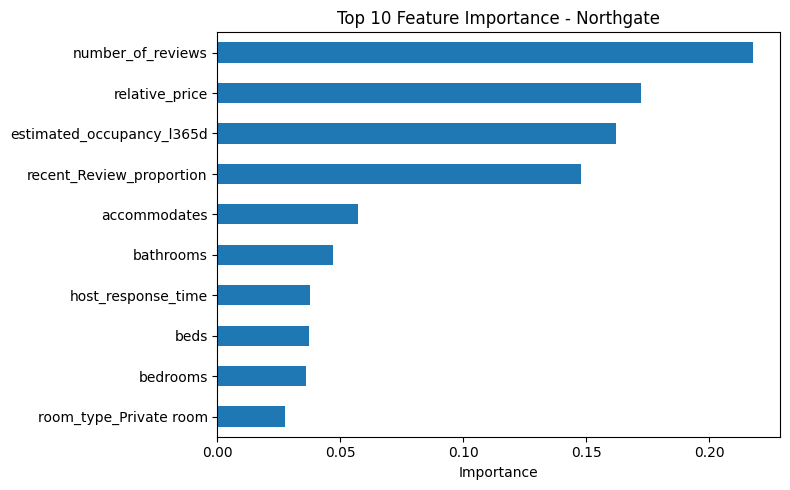

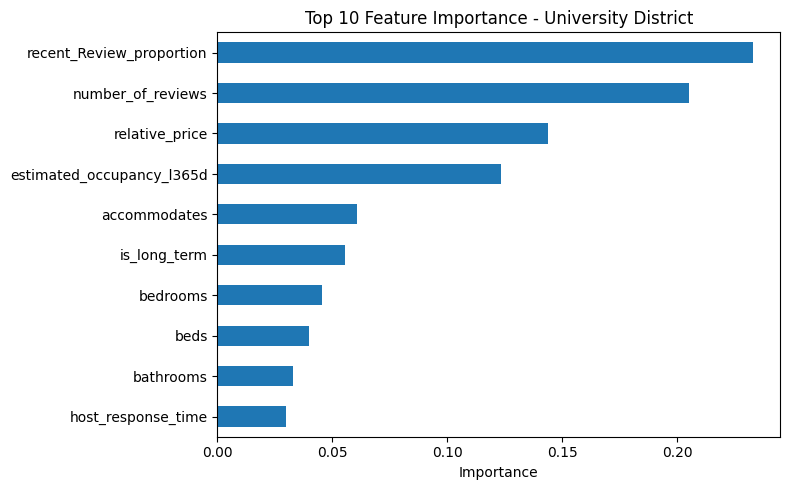

In [358]:
for area_name, result in all_results.items():
    plt.figure(figsize=(8, 5))
    result["top_features"].sort_values(ascending=True).plot(kind="barh")
    plt.title(f"Top 10 Feature Importance - {area_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()